In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Task 12

In [58]:
# Calculate the diaganoal
Q = np.array([
    [-0.0085,  0.005,  0.0025,  0,      0.001],
    [ 0,      -0.014,  0.005,   0.004,  0.005],
    [ 0,       0,     -0.008,   0.003,  0.005],
    [ 0,       0,      0,      -0.009,  0.009],
    [ 0,       0,      0,       0,      0    ]
])

In [67]:
rng = np.random.default_rng(30)

Y = []

for i in range(1_000):
    # Initial parameters
    curr_state = 0
    t = 0
    obs = [curr_state]
    next_obs_time = 48

    while True:
        # Exclude current state as next possible state
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        # Draw transition time
        q = Q[curr_state,curr_state]
        holding_time = rng.exponential(-1 / q)
        jump_time = t + holding_time

        # Record all observation times that occur before the jump
        while next_obs_time <= jump_time:
            obs.append(int(curr_state))
            next_obs_time += 48

        # Create poperbilities
        props = Q[curr_state, possible_states] / -q

        # Draw next state
        new_state = rng.choice(possible_states, p=props)

        # Check if state 4 (death)
        if new_state == 4:
            obs.append(4)
            break

        # Update time and state
        t = jump_time
        curr_state = new_state

    
    # Append list to combined list
    Y.append(obs)


In [68]:
Y

[[0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 4],
 [0, 1, 1, 3, 4],
 [0, 0, 0, 0, 0, 4],
 [0, 0, 2, 2, 2, 4],
 [0, 2, 4],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 2, 2, 2, 3, 3, 4],
 [0, 0, 0, 2, 2, 2, 3, 3, 4],
 [0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 4],
 [0, 0, 0, 1, 4],
 [0, 1, 1, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 3, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 0, 0, 2, 3, 3, 3, 4],
 [0, 1, 1, 1, 3, 4],
 [0, 0, 1, 2, 2, 4],
 [0, 4],
 [0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4],
 [0, 0, 4],
 [0, 1, 1, 4],
 [0, 1, 1, 4],
 [0, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 1, 1, 4],
 [0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 4],
 [0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 4],
 [0, 0, 1, 4],
 [0, 0, 2, 2, 2, 2, 4],
 [0, 1, 2, 2, 2, 3, 3, 3, 4],
 [0, 0, 0, 1, 1, 4],
 [0, 1, 4],
 [0, 0, 2, 3, 4],
 [0, 0, 1, 1, 2, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 4],
 [0, 1, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 4],
 [0,

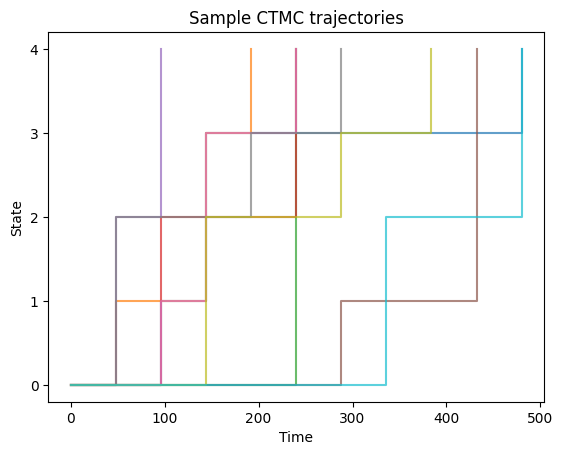

In [70]:
for i in range(10):  # plot first 10 trajectories
    plt.step([i*48 for i in range(len(Y[i]))], Y[i], where="post", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("State")
plt.yticks([0,1,2,3,4])
plt.title("Sample CTMC trajectories")
plt.show()

# Task 13

In [49]:
# Create initial guess
Q0 = np.zeros((5,5))
Q0[np.triu_indices(5, 1)] = 0.5

# Calculate diagonals
q11 = -np.sum(Q0[0,:])
q22 = -np.sum(Q0[1,:])
q33 = -np.sum(Q0[2,:])
q44 = -np.sum(Q0[3,:])
q55 = 0

# Set diagonals
Q0[[0,1,2,3,4], [0,1,2,3,4]] = [q11, q22, q33, q44, q55]

Q0

array([[-2. ,  0.5,  0.5,  0.5,  0.5],
       [ 0. , -1.5,  0.5,  0.5,  0.5],
       [ 0. ,  0. , -1. ,  0.5,  0.5],
       [ 0. ,  0. ,  0. , -0.5,  0.5],
       [ 0. ,  0. ,  0. ,  0. ,  0. ]])

In [79]:
Qk = np.copy(Q0)

for w in range(len(Y)):
    # Get current time series
    yw = Y[w]
    
    # Inital paramerts
    curr_state = yw[0]
    next_obs_time = 48

    # Sim states
    sim = []

    while True:
        new_sim = []

        # Exclude current state as next possible state
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        # Draw transition time
        q = Q[curr_state,curr_state]
        s = rng.exponential(-1 / q)

        # Draw transition time
        q = Q[curr_state,curr_state]
        holding_time = rng.exponential(-1 / q)
        jump_time = next_obs_time + holding_time

        # Record all observation times that occur before the jump
        next_obs_time_new = next_obs_time
        while next_obs_time_new <= jump_time:
            # Check if state match observed
            new_sim.append(curr_state)
            next_obs_time_new += 48

        # Check if match
        if (sim + new_sim) == yw[:len(sim)]:
            next_obs_time = next_obs_time_new
            sim = sim + new_sim

            # Create poperbilities and draw next state
            props = Q[curr_state, possible_states] / -q
            new_state = rng.choice(possible_states, p=props)

            if new_state == 4:
                break

            curr_state = new_state

            
        

    

KeyboardInterrupt: 

In [76]:
[0,0,1] + [3,4]

[0, 0, 1, 3, 4]

In [74]:
[i for i in range(4)]

[0, 1, 2, 3]

In [ ]:
Qk = np.copy(Q0)

# Counters for estimating Q
N = np.zeros((5, 5))
S = np.zeros(5)

for yw in Y:

    # Loop over observed intervals
    for j in range(len(yw) - 1):

        start_state = yw[j]
        end_state   = yw[j + 1]

        while True:  # rejection sampling

            curr_state = start_state
            t = 0.0

            interval_jumps = []
            interval_times = np.zeros(5)

            # Simulate until 48 months
            while t < 48:

                q = Qk[curr_state, curr_state]

                # absorbing death state
                if curr_state == 4:
                    interval_times[4] += (48 - t)
                    t = 48
                    break

                holding = rng.exponential(-1 / q)

                # no jump before end of interval
                if t + holding >= 48:
                    interval_times[curr_state] += (48 - t)
                    t = 48
                    break

                # jump occurs
                interval_times[curr_state] += holding
                t += holding

                possible_states = [0,1,2,3,4]
                possible_states.pop(curr_state)

                probs = Qk[curr_state, possible_states] / (-q)

                new_state = rng.choice(possible_states, p=probs)

                interval_jumps.append((curr_state, new_state))

                curr_state = new_state

            # Accept if state at month 48 matches observation
            if curr_state == end_state:

                # Update sufficient statistics
                S += interval_times

                for i, k in interval_jumps:
                    N[i, k] += 1

                break